In [3]:
# ================================================
# Phase 1: Data Exploration and Problem Framing
# ================================================
# Import required libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

In [4]:
from google.colab import files
uploaded = files.upload()

Saving employee_job_change.csv to employee_job_change.csv


In [5]:
# Load Employee Attrition - Job Change Prediction dataset
df = pd.read_csv("employee_job_change.csv")

# Display first few rows to understand data structure
df.head()

,Enrollee_id,City,City_development_index,Gender,Relevent_experience,Enrolled_university,Education_level,Major_discipline,Experience,Company_size,Company_type,Last_new_job,Training_hours,Target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0


In [6]:
# Check dataset dimensions
print("Shape:", df.shape)

Shape: (19158, 14)


In [7]:
# View Column names
df.columns

Index(['Enrollee_id', 'City', 'City_development_index', 'Gender',
       'Relevent_experience', 'Enrolled_university', 'Education_level',
       'Major_discipline', 'Experience', 'Company_size', 'Company_type',
       'Last_new_job', 'Training_hours', 'Target'],
      dtype='object')

In [8]:
# Get data types and missing value information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Enrollee_id             19158 non-null  int64  
 1   City                    19158 non-null  object 
 2   City_development_index  19158 non-null  float64
 3   Gender                  14650 non-null  object 
 4   Relevent_experience     19158 non-null  object 
 5   Enrolled_university     18772 non-null  object 
 6   Education_level         18698 non-null  object 
 7   Major_discipline        16345 non-null  object 
 8   Experience              19093 non-null  object 
 9   Company_size            13220 non-null  object 
 10  Company_type            13018 non-null  object 
 11  Last_new_job            18735 non-null  object 
 12  Training_hours          19158 non-null  int64  
 13  Target                  19158 non-null  int64  
dtypes: float64(1), int64(3), object(10)
me

In [9]:
# Statistical summary of numerical columns
df.describe()

,Enrollee_id,City_development_index,Training_hours,Target
count,19158.000000,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,65.366896,0.249348
std,9616.292592,0.123362,60.058462,0.432647
min,1.000000,0.448000,1.000000,0.000000
25%,8554.250000,0.740000,23.000000,0.000000
50%,16982.500000,0.903000,47.000000,0.000000
75%,25169.750000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000


In [10]:
# Checking missing values and their percentage in each feature
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_%": missing_percent
}).sort_values(by="Missing_%", ascending=False)
# Display only columns with missing values
missing_df[missing_df["Missing_Count"] > 0]

,Missing_Count,Missing_%
Company_type,6140,32.049274
Company_size,5938,30.994885
Gender,4508,23.530640
Major_discipline,2813,14.683161
Education_level,460,2.401086
Last_new_job,423,2.207955
Enrolled_university,386,2.014824
Experience,65,0.339284


In [11]:
# Separating categorical and numerical columns based on data type
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

print("Categorical Columns:", cat_cols)
print("Numerical Columns:", num_cols)

Categorical Columns: Index(['City', 'Gender', 'Relevent_experience', 'Enrolled_university',
       'Education_level', 'Major_discipline', 'Experience', 'Company_size',
       'Company_type', 'Last_new_job'],
      dtype='object')
Numerical Columns: Index(['Enrollee_id', 'City_development_index', 'Training_hours', 'Target'], dtype='object')


In [12]:
# Checking number of unique values in each categorical feature
# Helps identify high-cardinality columns
for col in cat_cols:
    print(col, ": ", df[col].nunique())

City :  123
Gender :  3
Relevent_experience :  2
Enrolled_university :  3
Education_level :  5
Major_discipline :  6
Experience :  22
Company_size :  8
Company_type :  6
Last_new_job :  6


In [13]:
# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns

# Print unique values for each categorical column
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: City
['city_103' 'city_40' 'city_21' 'city_115' 'city_162' 'city_176'
 'city_160' 'city_46' 'city_61' 'city_114' 'city_13' 'city_159' 'city_102'
 'city_67' 'city_100' 'city_16' 'city_71' 'city_104' 'city_64' 'city_101'
 'city_83' 'city_105' 'city_73' 'city_75' 'city_41' 'city_11' 'city_93'
 'city_90' 'city_36' 'city_20' 'city_57' 'city_152' 'city_19' 'city_65'
 'city_74' 'city_173' 'city_136' 'city_98' 'city_97' 'city_50' 'city_138'
 'city_82' 'city_157' 'city_89' 'city_150' 'city_70' 'city_175' 'city_94'
 'city_28' 'city_59' 'city_165' 'city_145' 'city_142' 'city_26' 'city_12'
 'city_37' 'city_43' 'city_116' 'city_23' 'city_99' 'city_149' 'city_10'
 'city_45' 'city_80' 'city_128' 'city_158' 'city_123' 'city_7' 'city_72'
 'city_106' 'city_143' 'city_78' 'city_109' 'city_24' 'city_134' 'city_48'
 'city_144' 'city_91' 'city_146' 'city_133' 'city_126' 'city_118' 'city_9'
 'city_167' 'city_27' 'city_84' 'city_54' 'city_39' 'city_79' 'city_76'
 'city_77' 'city_81' 'city_131' 'city_

In [14]:
# Identifying ordinal categorical features by inspecting unique values
ordinal_candidates = ['Education_level','Experience','Last_new_job']

for col in ordinal_candidates:
    print(col, df[col].unique())

Education_level ['Graduate' 'Masters' 'High School' nan 'Phd' 'Primary School']
Experience ['>20' '15' '5' '<1' '11' '13' '7' '17' '2' '16' '1' '4' '10' '14' '18'
 '19' '12' '3' '6' '9' '8' '20' nan]
Last_new_job ['1' '>4' 'never' '4' '3' '2' nan]


In [15]:
# Check class distribution of target variable
class_dist = pd.DataFrame({
    'Count': df['Target'].value_counts(),
    'Percentage (%)': df['Target'].value_counts(normalize=True) * 100
})
class_dist

,Count,Percentage (%)
Target,,
0,14381,75.065247
1,4777,24.934753


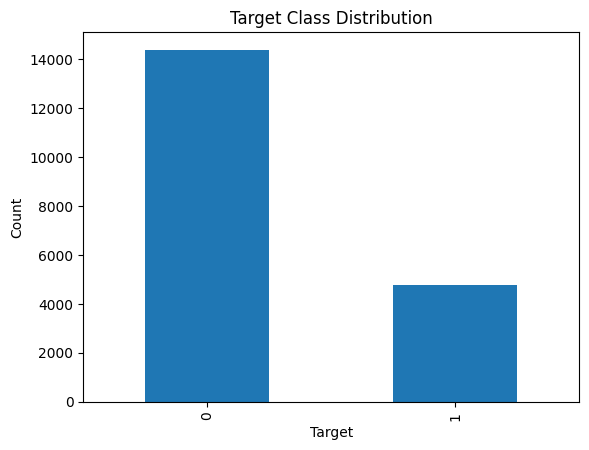

In [16]:
# target class distribution graph
df['Target'].value_counts().plot(kind='bar')
plt.title("Target Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

In [17]:
# Selecting true numerical features for outlier analysis
num_cols = ['Training_hours', 'City_development_index']

# Using IQR method to statistically detect outliers
for col in num_cols:
 Q1 = df[col].quantile(0.25)
 Q3 = df[col].quantile(0.75)
 IQR = Q3 - Q1
 lower = Q1 - 1.5 * IQR
 upper = Q3 + 1.5 * IQR
 outliers = df[(df[col] < lower) | (df[col] > upper)]
 print(f"Column: {col}")
 print(f"Outliers: {len(outliers)}")
 print("-" * 30)

Column: Training_hours
Outliers: 984
------------------------------
Column: City_development_index
Outliers: 17
------------------------------


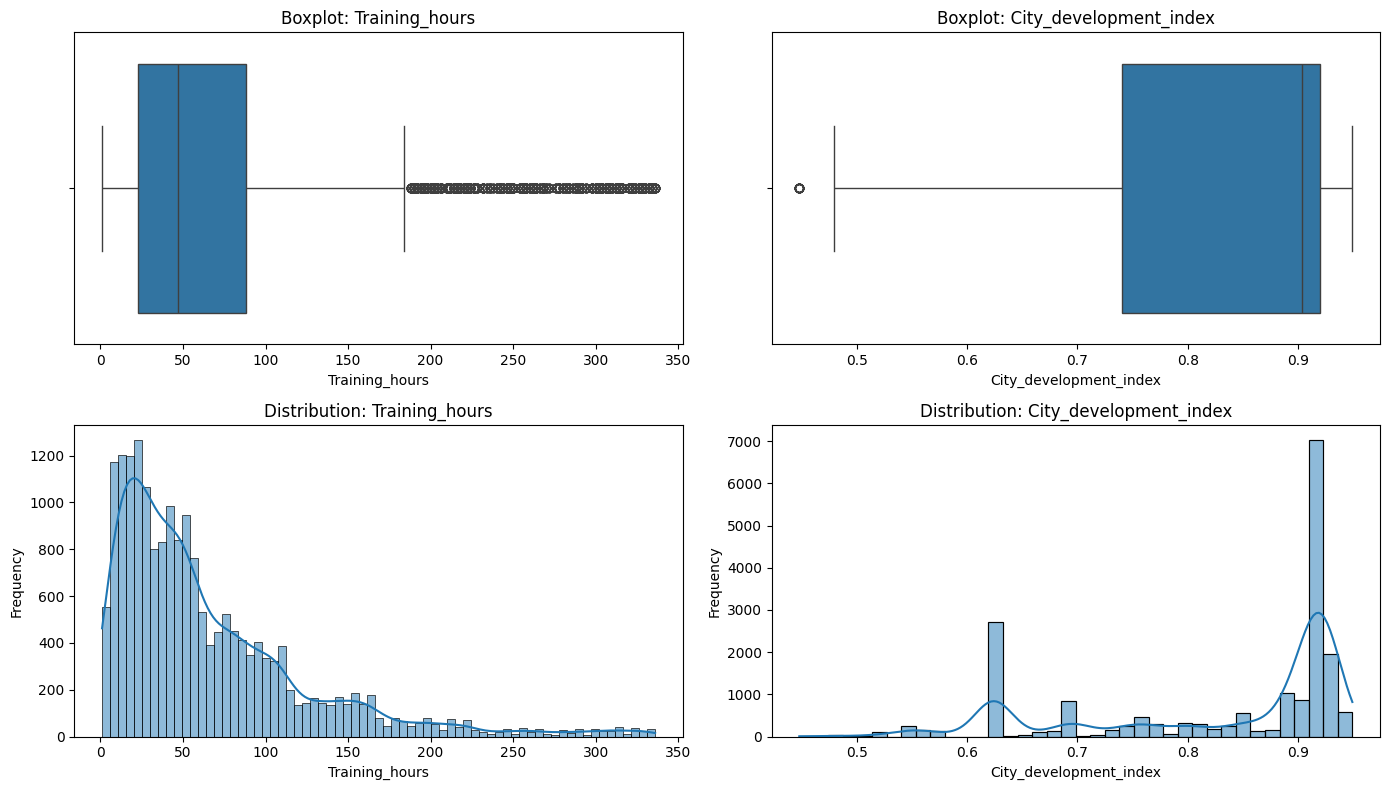

In [18]:
plt.figure(figsize=(14,8))

# Boxplot - Training_hours
plt.subplot(2,2,1)
sns.boxplot(x=df['Training_hours'])
plt.title('Boxplot: Training_hours')

# Boxplot - City_development_index
plt.subplot(2,2,2)
sns.boxplot(x=df['City_development_index'])
plt.title('Boxplot: City_development_index')

# Distribution - Training_hours
plt.subplot(2,2,3)
sns.histplot(df['Training_hours'], kde=True)
plt.title('Distribution: Training_hours')
plt.xlabel('Training_hours')
plt.ylabel('Frequency')

# Distribution - City_development_index
plt.subplot(2,2,4)
sns.histplot(df['City_development_index'], kde=True)
plt.title('Distribution: City_development_index')
plt.xlabel('City_development_index')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [19]:
# ========================================
# Phase 4: Preprocessing Pipeline Design
# ========================================

In [20]:
# Correct invalid category caused by Excel auto-date conversion
df['Company_size'] = df['Company_size'].replace('Oct-49', '10-49')

In [21]:
# Target variable
y = df['Target']

# Drop target and identifier column from features
X = df.drop(columns=['Target', 'Enrollee_id'])

In [22]:
y.sample(2)

,Target
10208,0
6567,1


In [23]:
X.sample(2)

,City,City_development_index,Gender,Relevent_experience,Enrolled_university,Education_level,Major_discipline,Experience,Company_size,Company_type,Last_new_job,Training_hours
7749,city_97,0.925,Male,Has relevent experience,no_enrollment,Graduate,STEM,15,1000-4999,Pvt Ltd,4,108
13769,city_67,0.855,Male,Has relevent experience,no_enrollment,Graduate,STEM,15,NaN,NaN,1,24


In [39]:
# Function to handle outliers using IQR-based capping (Winsorization)
def iqr_capping(df, columns):
    # Create a copy of the dataframe to avoid modifying the original data
    df = df.copy()

    # Apply capping to each numerical column
    for col in columns:
        # Calculate first and third quartiles
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        # Compute Interquartile Range (IQR)
        IQR = Q3 - Q1

        # Define lower and upper bounds for outliers
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # Cap values outside the IQR range to the boundary values
        df[col] = df[col].clip(lower, upper)

    # Return the dataframe with capped outliers
    return df


# List of numerical columns where outlier handling is required
num_cols = ['Training_hours', 'City_development_index']

# Apply IQR-based outlier capping to the dataset
df = iqr_capping(df, num_cols)

In [26]:
# Train–Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
# Numerical features
num_cols = ['Training_hours', 'City_development_index']

# Ordinal categorical features
ordinal_cols = ['Education_level', 'Experience', 'Last_new_job']

# Nominal categorical features
nominal_cols = [
    'Gender',
    'Major_discipline',
    'Company_type',
    'Company_size',
    'City',
    'Enrolled_university',
    'Relevent_experience',
    'Enrolled_university'
]

In [28]:
# Define Ordinal Category Orderings
education_order = ['Primary School', 'High School', 'Graduate', 'Masters', 'Phd']
experience_order = ['<1'] + [str(i) for i in range(1, 21)] + ['>20']
last_new_job_order = ['never', '1', '2', '3', '4', '>4']

In [29]:
# Numerical Pipeline
#(Median imputation + scaling)
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [30]:
# Ordinal Categorical Pipeline
# (Mode imputation + ordinal encoding)
ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[
        education_order,
        experience_order,
        last_new_job_order
    ]))
])

In [31]:
# Nominal Categorical Pipeline
# (Mode imputation + one-hot encoding)
nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [32]:
# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('ord', ordinal_pipeline, ordinal_cols),
    ('nom', nominal_pipeline, nominal_cols)
])

In [33]:
# Apply Preprocessing Pipeline
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [34]:
print("Training data shape after preprocessing:", X_train_processed.shape)
print("Testing data shape after preprocessing:", X_test_processed.shape)

Training data shape after preprocessing: (15326, 158)
Testing data shape after preprocessing: (3832, 158)


In [35]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Convert processed training data back to DataFrame
X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

# Preview encoded data
X_train_processed.head()

,num__Training_hours,num__City_development_index,ord__Education_level,ord__Experience,ord__Last_new_job,nom__Gender_Female,nom__Gender_Male,nom__Gender_Other,nom__Major_discipline_Arts,nom__Major_discipline_Business Degree,...,nom__City_city_98,nom__City_city_99,nom__Enrolled_university_Full time course,nom__Enrolled_university_Part time course,nom__Enrolled_university_no_enrollment,nom__Relevent_experience_Has relevent experience,nom__Relevent_experience_No relevent experience,nom__Enrolled_university_Full time course,nom__Enrolled_university_Part time course,nom__Enrolled_university_no_enrollment
17855,0.411648,-1.672102,2.0,10.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
17664,-0.839076,0.734358,0.0,5.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
13404,-0.488873,0.539240,2.0,12.0,5.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
13366,-0.205376,0.734358,2.0,5.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
15670,1.545638,0.205913,2.0,5.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [36]:
# Verify missing values are gone
X_train_processed.isnull().sum().sum()

np.int64(0)

In [37]:
# Verify scaling (mean ≈ 0, std ≈ 1)
X_train_processed[['num__Training_hours',
                 'num__City_development_index']].describe()

,num__Training_hours,num__City_development_index
count,1.532600e+04,1.532600e+04
mean,-2.781715e-17,-1.784934e-16
std,1.000033e+00,1.000033e+00
min,-1.072545e+00,-3.102970e+00
25%,-7.056654e-01,-7.127696e-01
50%,-3.054337e-01,6.530592e-01
75%,3.782955e-01,7.343585e-01
max,4.514023e+00,9.701265e-01


In [40]:
# ====================================================
# Phase 5: Model Performance and Preprocessing Impact Analysis
# ====================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import pandas as pd
import matplotlib.pyplot as plt

In [41]:
# Evaluation Function
def evaluate(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    }

In [42]:
# Baseline Models (No PCA, No SMOTE)
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

df_baseline = pd.DataFrame({
    "Logistic Regression": evaluate(lr, X_train_processed, X_test_processed, y_train, y_test),
    "Random Forest": evaluate(rf, X_train_processed, X_test_processed, y_train, y_test)
}).T

df_baseline

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.777140,0.597303,0.324607,0.420624
Random Forest,0.770877,0.553547,0.416754,0.475508


In [43]:
# Models WITH SMOTE (No PCA)
lr_smote = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("lr", LogisticRegression(max_iter=1000))
])

rf_smote = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(n_estimators=100, random_state=42))
])

df_smote = pd.DataFrame({
    "Logistic Regression + SMOTE": evaluate(lr_smote, X_train_processed, X_test_processed, y_train, y_test),
    "Random Forest + SMOTE": evaluate(rf_smote, X_train_processed, X_test_processed, y_train, y_test)
}).T

df_smote

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,Accuracy,Precision,Recall,F1-Score
Logistic Regression + SMOTE,0.737474,0.482594,0.740314,0.584298
Random Forest + SMOTE,0.772182,0.548463,0.485864,0.515269


In [44]:
# PCA Actual Component Verification
pca = PCA(n_components=0.95, random_state=42)
pca.fit(X_train_processed)

print("Original features:", X_train_processed.shape[1])
print("Actual PCA components (95% variance):", pca.n_components_)

Original features: 158
Actual PCA components (95% variance): 6


In [45]:
# Models WITH PCA (Using Actual Components)
lr_pca = Pipeline([
    ("pca", PCA(n_components=0.95)),
    ("lr", LogisticRegression(max_iter=1000))
])

rf_pca = Pipeline([
    ("pca", PCA(n_components=0.95)),
    ("rf", RandomForestClassifier(n_estimators=100, random_state=42))
])

df_pca = pd.DataFrame({
    "Logistic Regression + PCA": evaluate(lr_pca, X_train_processed, X_test_processed, y_train, y_test),
    "Random Forest + PCA": evaluate(rf_pca, X_train_processed, X_test_processed, y_train, y_test)
}).T

df_pca

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


,Accuracy,Precision,Recall,F1-Score
Logistic Regression + PCA,0.769833,0.595801,0.237696,0.339820
Random Forest + PCA,0.768789,0.549075,0.404188,0.465621


In [46]:
# Final Comparison Table
final_results = pd.concat([df_baseline, df_smote, df_pca])
final_results.round(3)

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.777,0.597,0.325,0.421
Random Forest,0.771,0.554,0.417,0.476
Logistic Regression + SMOTE,0.737,0.483,0.740,0.584
Random Forest + SMOTE,0.772,0.548,0.486,0.515
Logistic Regression + PCA,0.770,0.596,0.238,0.340
Random Forest + PCA,0.769,0.549,0.404,0.466


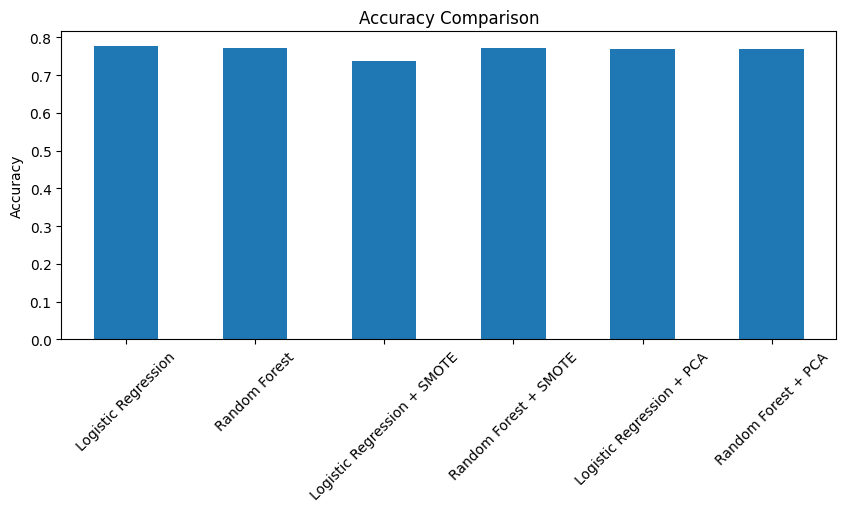

In [47]:
# Accuracy Plotting
final_results["Accuracy"].plot(kind="bar", figsize=(10,4))
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

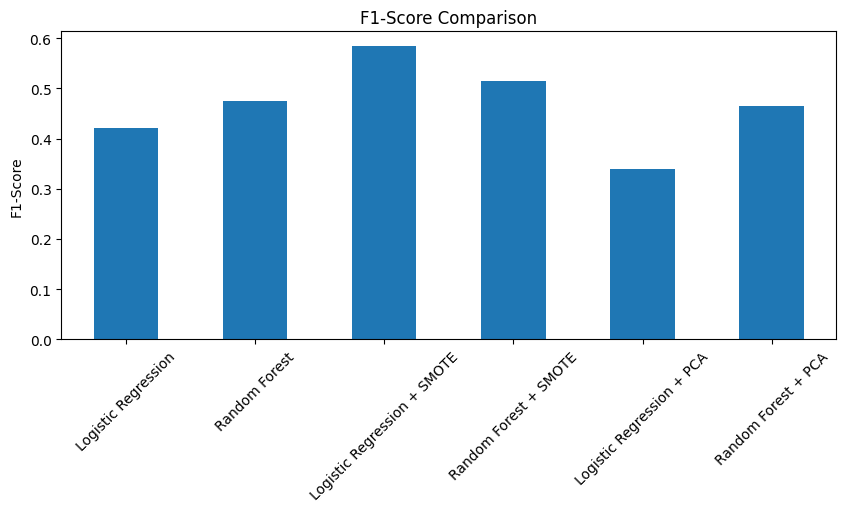

In [48]:
# F1 Score Plotting
final_results["F1-Score"].plot(kind="bar", figsize=(10,4))
plt.title("F1-Score Comparison")
plt.ylabel("F1-Score")
plt.xticks(rotation=45)
plt.show()

In [49]:
# PCA Feature Contribution (USING ACTUAL COMPONENTS)
# Fit PCA with 95% variance
pca_full = PCA(n_components=0.95)
X_pca = pca_full.fit_transform(X_train_processed)

# Create loadings dataframe (ALL PCs)
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=X_train_processed.columns,
    columns=[f"PC{i+1}" for i in range(pca_full.n_components_)]
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6
num__Training_hours,0.001321,-0.006340,0.988494,-0.147170,-0.025536,0.012042
num__City_development_index,0.049384,0.046957,0.137873,0.930750,-0.029972,0.100515
ord__Education_level,0.028152,0.041436,-0.018661,-0.075695,0.299013,0.850477
ord__Experience,0.989652,-0.128037,-0.009604,-0.043778,-0.042175,-0.013299
ord__Last_new_job,0.119793,0.983854,-0.004959,-0.056794,-0.110273,-0.029487
...,...,...,...,...,...,...
nom__Relevent_experience_Has relevent experience,0.022383,0.038645,0.010632,-0.036689,0.308375,0.056587
nom__Relevent_experience_No relevent experience,-0.022383,-0.038645,-0.010632,0.036689,-0.308375,-0.056587
nom__Enrolled_university_Full time course,-0.018331,-0.035631,-0.017718,-0.038694,-0.375210,0.187898
nom__Enrolled_university_Part time course,-0.002793,0.001714,0.002567,0.001104,-0.048613,0.047726
